In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales.csv")

In [3]:
df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   str    
 1   Category  1821 non-null   str    
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   str    
dtypes: float64(3), str(3)
memory usage: 124.3 KB


In [5]:
df.describe()

,Sales,Quantity,Profit
count,1823.000000,1820.000000,1825.000000
mean,980.482677,10.053846,248.696130
std,336.756618,5.515370,118.159627
min,0.000000,0.000000,0.000000
25%,784.071354,5.000000,156.916498
50%,997.725134,10.000000,229.344557
75%,1208.512721,15.000000,324.867847
max,1888.932537,19.000000,703.228418


In [6]:
df.shape

(1825, 6)

# Data Exploration

In [7]:
df.isna().any()

Date        False
Category     True
Sales        True
Quantity     True
Profit      False
Region       True
dtype: bool

In [8]:
df.dropna(inplace=True)
df = df.reset_index(drop=True)

In [9]:
df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


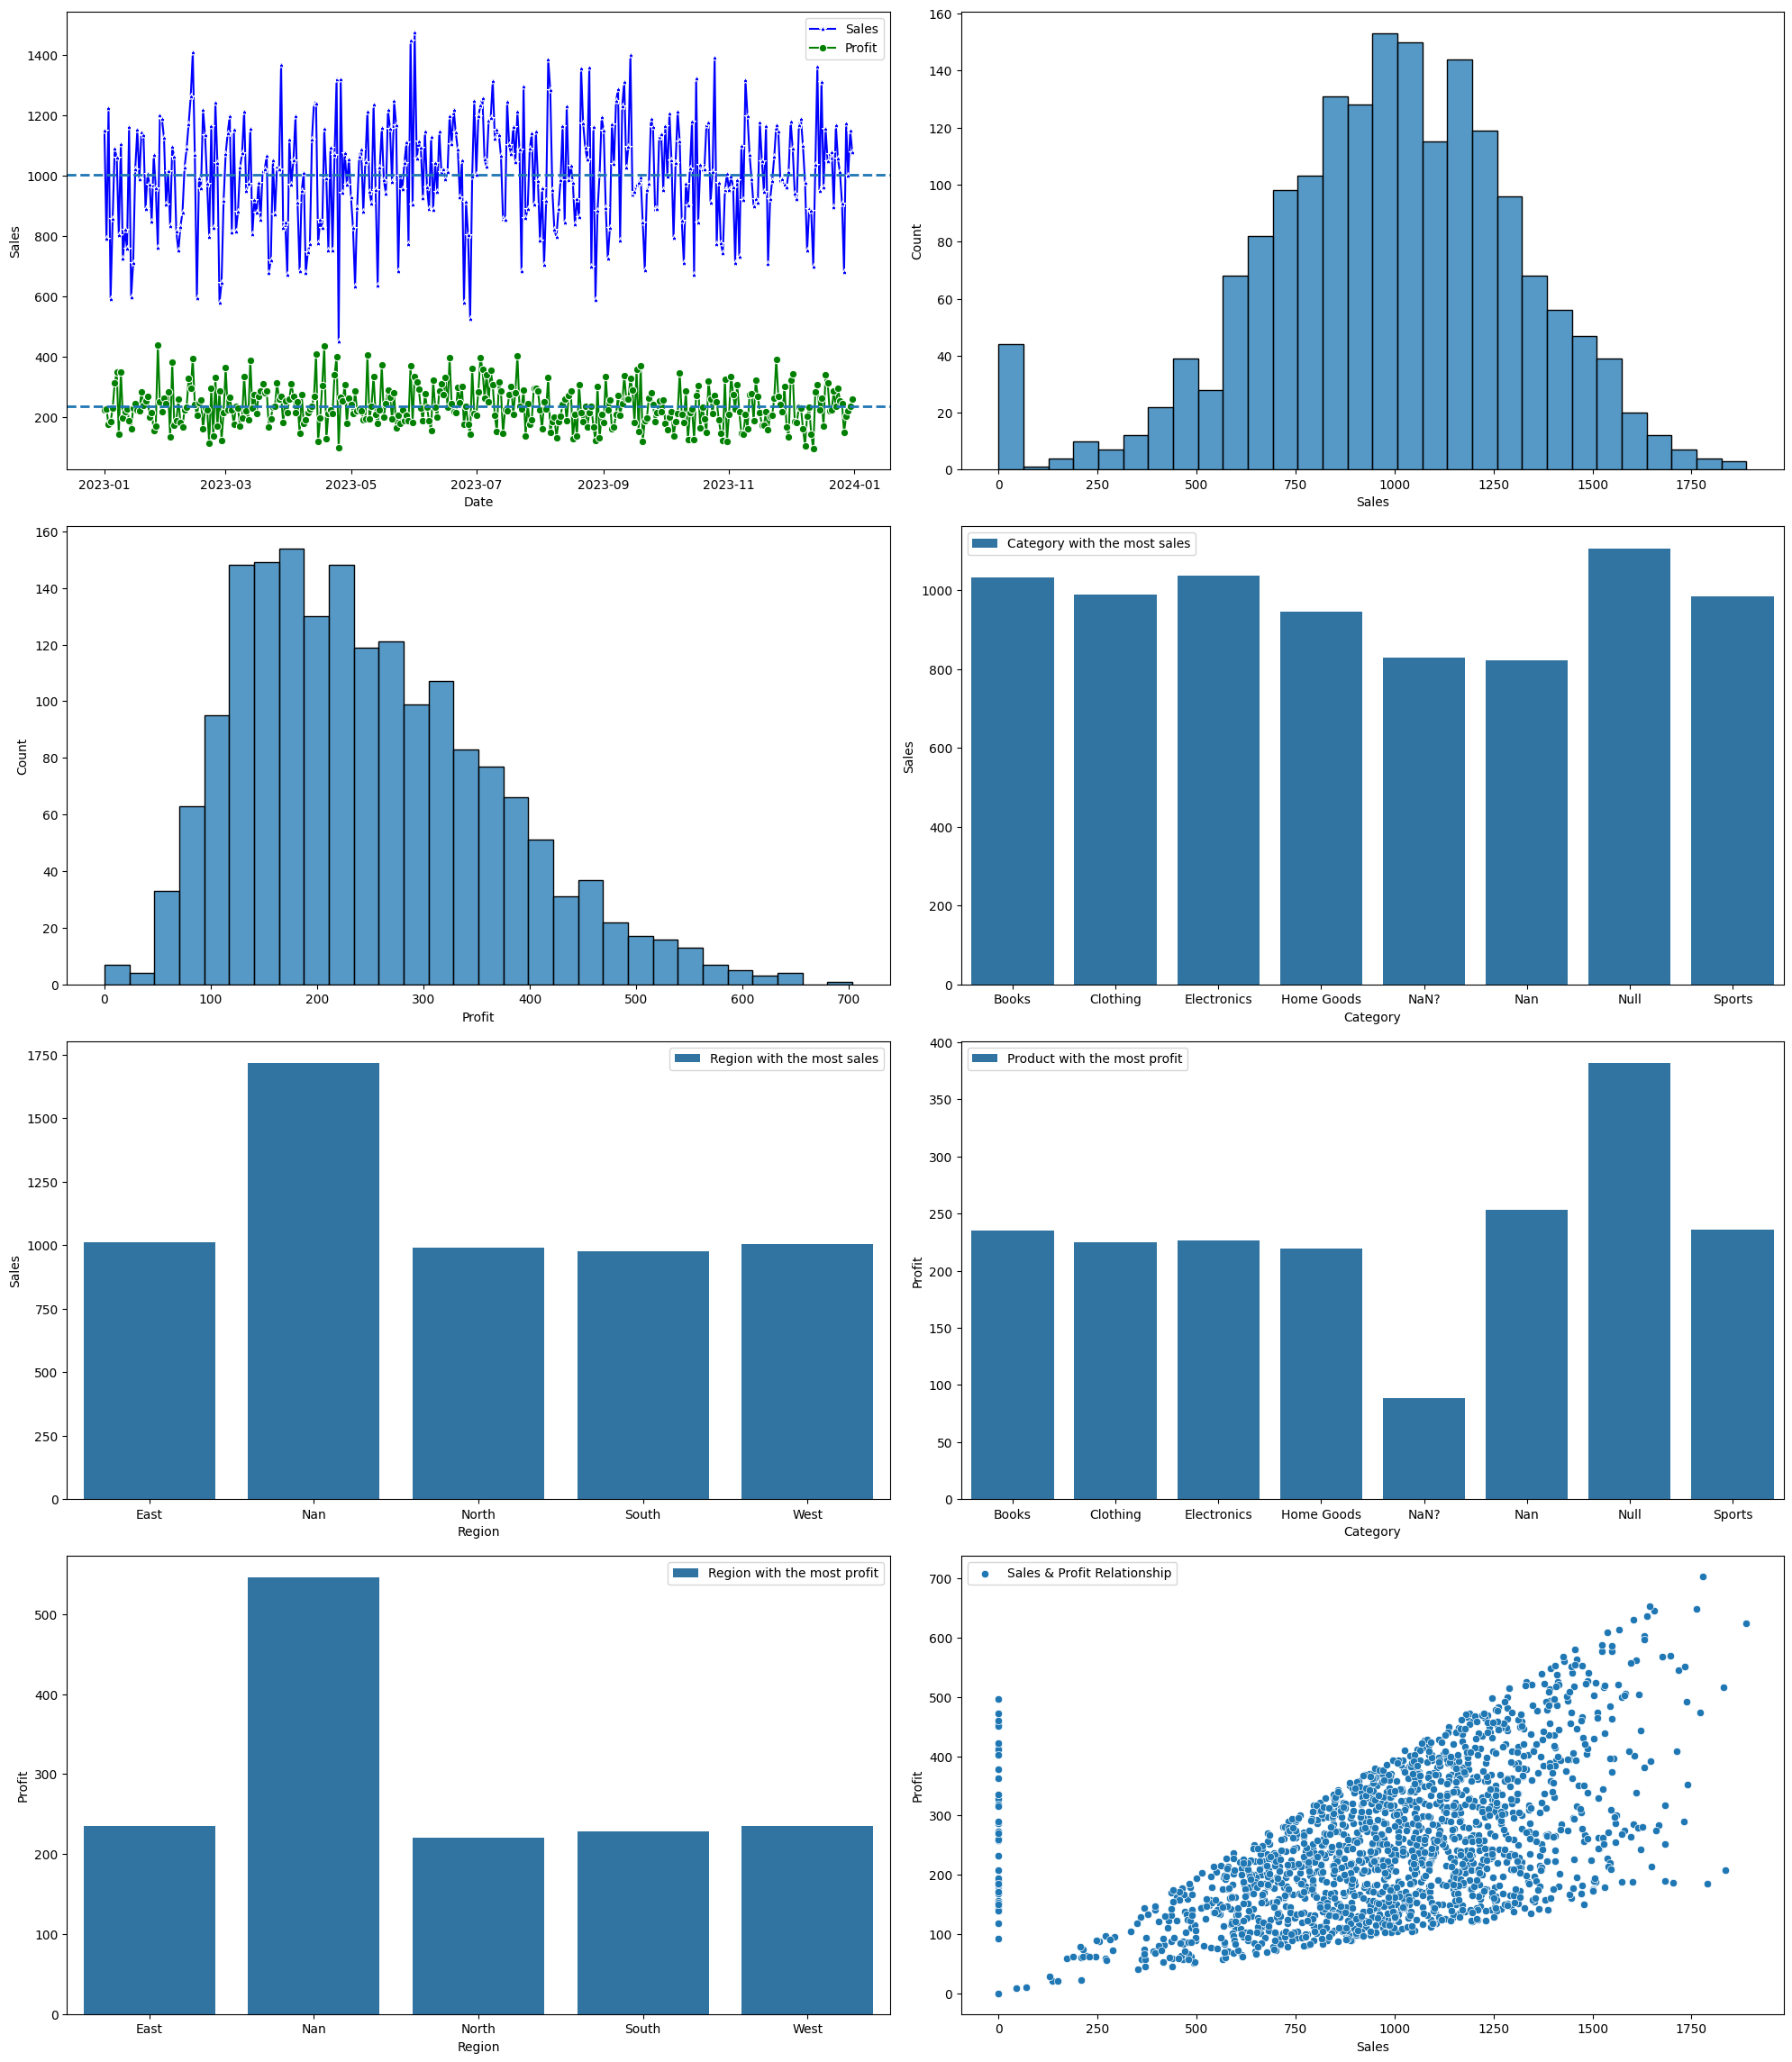

In [10]:
# side by side plotting to derive insights

#Grouping for other plots

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(by="Date")

date_group = df.groupby("Date")[["Sales", "Profit"]].median().reset_index()
sales_mean = date_group["Sales"].mean()
profit_mean = date_group["Profit"].mean()

cat_group = df.groupby("Category")[["Sales", "Profit"]].median().reset_index()

reg_group = df.groupby("Region")[["Sales", "Profit"]].median().reset_index()

fig, axes = plt.subplots(4, 2, figsize=(20, 23))

sns.lineplot(data=date_group, x="Date", y="Sales", marker="*", label="Sales", color="blue", ax=axes[0, 0])
sns.lineplot(data=date_group, x="Date", y="Profit", marker="o", label="Profit", color="green", ax=axes[0, 0])
axes[0, 0].axhline(sales_mean, linestyle="--", linewidth=2, label=f"Sales Mean: {sales_mean:.2f}")
axes[0, 0].axhline(profit_mean, linestyle="--", linewidth=2, label=f"Profit Mean: {profit_mean:.2f}")
sns.histplot(x=df["Sales"], bins=30, label="Daily Sales Distribution by Product Category", ax=axes[0, 1])

sns.histplot(x=df["Profit"], bins=30, label="Daily Profit Distribution by Product Categoty", ax=axes[1, 0])
sns.barplot(data=cat_group, x="Category", y="Sales", label="Category with the most sales", ax=axes[1, 1])

sns.barplot(data=reg_group, x="Region", y="Sales", label="Region with the most sales", ax=axes[2, 0])
sns.barplot(data=cat_group, x="Category", y="Profit", label="Product with the most profit", ax=axes[2, 1])
sns.barplot(data=reg_group, x="Region", y="Profit", label="Region with the most profit", ax=axes[3, 0])
sns.scatterplot(data=df, x="Sales", y="Profit", label="Sales & Profit Relationship", ax=axes[3, 1])

plt.tight_layout()
plt.show()



# Business Problem: We want to be able to predict what we will sell the next day for all product categories

In [11]:
new_df = df.groupby(["Date", "Category"])[["Sales", "Quantity", "Profit"]].median().reset_index()

In [12]:
new_df.head()

,Date,Category,Sales,Quantity,Profit
0,2023-01-01,Clothing,958.520710,7.0,224.054049
1,2023-01-01,Electronics,1149.014246,11.0,383.664245
2,2023-01-01,Home Goods,1473.763845,2.0,466.593090
3,2023-01-01,NaN?,828.585950,12.0,88.591355
4,2023-01-01,Sports,1230.230419,6.0,123.310460


In [13]:
new_df["Category"].unique()

<ArrowStringArray>
[   'Clothing', 'Electronics',  'Home Goods',        'NaN?',      'Sports',
       'Books',        'Null',         'Nan']
Length: 8, dtype: str

In [14]:
new_df = new_df[new_df["Category"].isin(['Clothing', 'Electronics', 'Home Goods', 'Sports', 'Books'])]

In [15]:
df_pivot = new_df.pivot(index="Date", columns="Category", values="Sales").reset_index()

In [16]:
df_pivot

Category,Date,Books,Clothing,Electronics,Home Goods,Sports
0,2023-01-01,NaN,958.520710,1149.014246,1473.763845,1230.230419
1,2023-01-02,1284.231946,788.996859,722.775149,358.113803,819.923845
2,2023-01-03,1232.110125,633.746905,NaN,1221.539974,NaN
3,2023-01-04,1391.098381,437.296968,NaN,589.965358,NaN
4,2023-01-05,585.784893,944.302307,856.000000,719.871148,1235.262456
...,...,...,...,...,...,...
360,2023-12-27,1404.515912,369.129481,680.960990,616.943267,1284.552563
361,2023-12-28,877.761968,1171.448421,1213.609516,989.446775,1310.164316
362,2023-12-29,1257.545552,999.843243,782.926023,1073.018142,371.968313
363,2023-12-30,856.742773,1188.630574,1250.682408,892.788671,1147.267364


In [17]:
df_pivot=df_pivot.fillna(df_pivot.median(numeric_only=True))

In [18]:
df_pivot.head()

Category,Date,Books,Clothing,Electronics,Home Goods,Sports
0,2023-01-01,1032.943587,958.520710,1149.014246,1473.763845,1230.230419
1,2023-01-02,1284.231946,788.996859,722.775149,358.113803,819.923845
2,2023-01-03,1232.110125,633.746905,1037.470835,1221.539974,984.097834
3,2023-01-04,1391.098381,437.296968,1037.470835,589.965358,984.097834
4,2023-01-05,585.784893,944.302307,856.000000,719.871148,1235.262456


In [19]:
df_pivot=df_pivot.sort_values(by="Date")

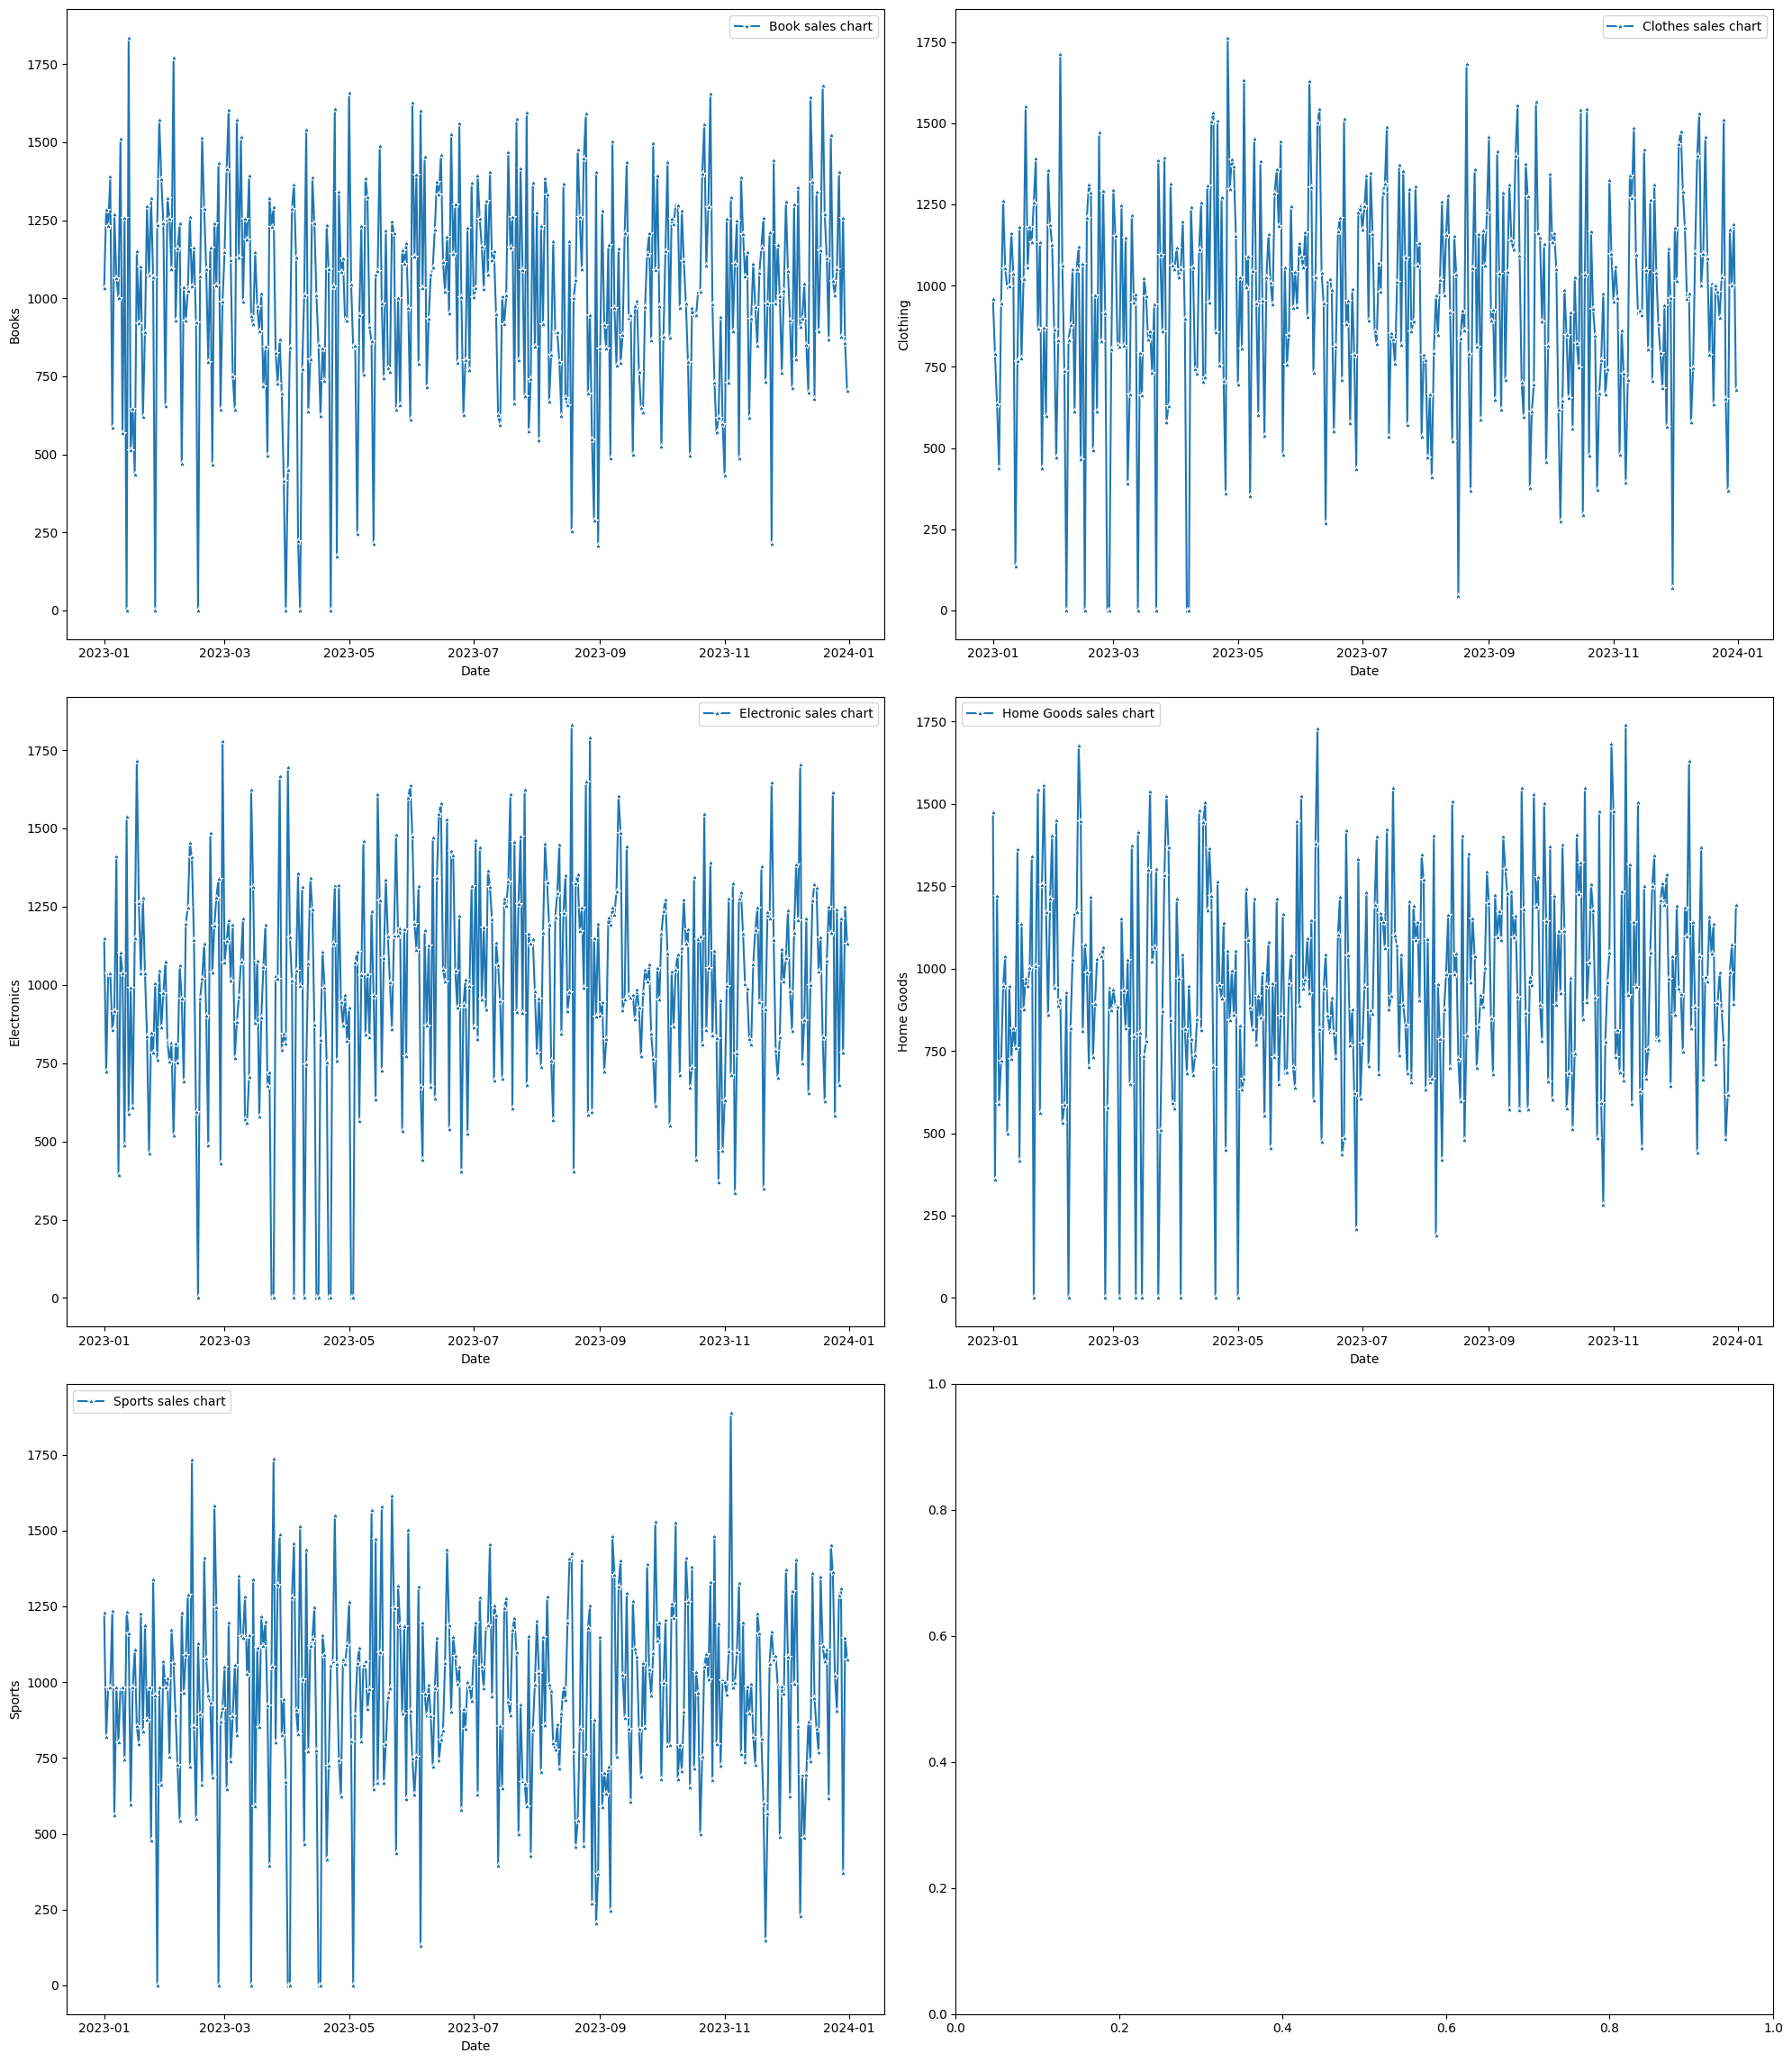

In [20]:
#Ploting line chart for all categories

fig, axes = plt.subplots(3, 2, figsize=(20, 23))
sns.lineplot(data=df_pivot, x="Date", y="Books", marker="*", label="Book sales chart", ax=axes[0, 0])
sns.lineplot(data=df_pivot, x="Date", y="Clothing", marker="*", label="Clothes sales chart", ax=axes[0, 1])
sns.lineplot(data=df_pivot, x="Date", y="Electronics", marker="*", label="Electronic sales chart", ax=axes[1, 0])
sns.lineplot(data=df_pivot, x="Date", y="Home Goods", marker="*", label="Home Goods sales chart", ax=axes[1, 1])
sns.lineplot(data=df_pivot, x="Date", y="Sports", marker="*", label="Sports sales chart", ax=axes[2, 0])
plt.tight_layout()
plt.show()

In [21]:
df_pivot.columns

Index(['Date', 'Books', 'Clothing', 'Electronics', 'Home Goods', 'Sports'], dtype='str', name='Category')

In [22]:
# Shifting rows

df_pivot[['Books_s', 'Clothing_s', 'Electronics_s', 'Home Goods_s', 'Sports_s']] = df_pivot[['Books', 'Clothing', 'Electronics', 'Home Goods', 'Sports']].shift(-1)

In [23]:
df_pivot = df_pivot.iloc[:-1]

In [24]:
X = np.array(df_pivot[['Books', 'Clothing', 'Electronics', 'Home Goods', 'Sports']])
y = np.array(df_pivot[['Books_s', 'Clothing_s', 'Electronics_s', 'Home Goods_s', 'Sports_s']])

In [25]:
X.shape, y.shape

((364, 5), (364, 5))

# Testing Regression Models

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [28]:
model = LinearRegression()
model_rf = RandomForestRegressor()
model.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
model.score(X_test, y_test)

-0.0596693276951686

In [30]:
model_rf.score(X_test, y_test)

-0.08021968253940921

In [31]:
X_train.shape

(291, 5)

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [34]:
mse = mean_squared_error(y_pred, y_test)
rmse = np.sqrt(mse)
print(f"MSE Value: {mse:.2f}")
print(f"RMSE Value: {rmse:.2f}")

MSE Value: 127731.64
RMSE Value: 357.40


# Model did not learn based on it large errors, most probably due to insufficient data depth

# Building my neural network from scratch

In [35]:
#Given X_train and y_train

print(X_train.shape)
print(y_train.shape)

(291, 5)
(291, 5)


In [36]:
#Transpose of the training data

X_train = X_train.T
y_train = y_train.T

In [37]:
def init_param():
    """
    Taking in 5 features, Trying to predict 5 output
    """
    # Layer 1: input (5), neuron (4)
    w1 = np.random.randn(4, 5) * 0.01
    b1 = np.zeros((4, 1))

    # Layer 2: hidden (4), output (5)
    w2 = np.random.randn(5, 4) * 0.01
    b2 = np.zeros((5, 1))

    return w1, b1, w2, b2

In [38]:
# Activation function for hidden layer
def ReLU(z):
    return np.maximum(0, z)

In [39]:
# Define forward pass
def forward_pass(x, w1, b1, w2, b2):
    z1 = w1.dot(x) + b1
    a1 = ReLU(z1)
    z2 = w2.dot(a1) + b2
    output = z2
    return z1, a1, z2, output

In [40]:
def deriv_ReLU(z):
    return z > 0

In [41]:
# Backward propagation
def backward_pass(x, y, z1, a1, z2, output, w2):
    m = y.shape[1]

    # Error for output layer
    dz2 = output - y

    # Gradients for output layer
    dw2 = 1/m * dz2.dot(a1.T)
    db2 = 1/m * np.sum(dz2, axis=1, keepdims=True)

    # Backprop into hidden layer
    dz1 = w2.T.dot(dz2) * deriv_ReLU(z1)

    # gradients for hidden layer
    dw1 = 1/m * dz1.dot(x.T)
    db1 = 1/m * np.sum(dz1, axis=1, keepdims=True)

    return dw1, db1, dw2, db2

In [42]:
# Updating parameters (w & b)
def update_params(w1, b1, w2, b2, alpha, dw1, db1, dw2, db2):

    w1 = w1 - dw1 * alpha
    b1 = b1 - db1 * alpha

    w2 = w2 - dw2 * alpha
    b2 = b2 - db2 * alpha
    return w1, b1, w2, b2

In [43]:
def MSE(output, y):
    m = y.shape[1]
    return np.mean((output - y) ** 2)

In [44]:
def gradient_descent(x, y, epoch, alpha):
    w1, b1, w2, b2 = init_param()
    for i in range(epoch):
        z1, a1, z2, output = forward_pass(x, w1, b1, w2, b2)
        dw1, db1, dw2, db2 = backward_pass(x, y, z1, a1, z2, output, w2)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, alpha, dw1, db1, dw2, db2)
        loss = MSE(output, y)
        print(f"Epoch: {i+1}, Loss: {loss:.2f}")
    return w1, b1, w2, b2

In [45]:
w1, b1, w2, b2 = gradient_descent(X_train, y_train, 50, 0.0001)

Epoch: 1, Loss: 1081745.12
Epoch: 2, Loss: 84076551.99
Epoch: 3, Loss: 1082894.39
Epoch: 4, Loss: 1082699.40
Epoch: 5, Loss: 1082504.44
Epoch: 6, Loss: 1082309.53
Epoch: 7, Loss: 1082114.65
Epoch: 8, Loss: 1081919.81
Epoch: 9, Loss: 1081725.02
Epoch: 10, Loss: 1081530.26
Epoch: 11, Loss: 1081335.54
Epoch: 12, Loss: 1081140.86
Epoch: 13, Loss: 1080946.21
Epoch: 14, Loss: 1080751.61
Epoch: 15, Loss: 1080557.05
Epoch: 16, Loss: 1080362.52
Epoch: 17, Loss: 1080168.03
Epoch: 18, Loss: 1079973.59
Epoch: 19, Loss: 1079779.18
Epoch: 20, Loss: 1079584.81
Epoch: 21, Loss: 1079390.48
Epoch: 22, Loss: 1079196.18
Epoch: 23, Loss: 1079001.93
Epoch: 24, Loss: 1078807.72
Epoch: 25, Loss: 1078613.54
Epoch: 26, Loss: 1078419.40
Epoch: 27, Loss: 1078225.31
Epoch: 28, Loss: 1078031.25
Epoch: 29, Loss: 1077837.23
Epoch: 30, Loss: 1077643.25
Epoch: 31, Loss: 1077449.30
Epoch: 32, Loss: 1077255.40
Epoch: 33, Loss: 1077061.53
Epoch: 34, Loss: 1076867.71
Epoch: 35, Loss: 1076673.92
Epoch: 36, Loss: 1076480.17


# The loss is still very high, we need more data to be able to make effective and reliable predictions